In [1]:
from datascience import *
import numpy as np
import matplotlib

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

import warnings
warnings.simplefilter("ignore")

## Review of the Steps in Classification & Functions ##

- `distance(pt1, pt2)`: Returns the distance between the arrays `pt1` and `pt2`
- `row_distance(row1, row2)`: Returns the distance between the rows `row1` and `row2`
- `distances(training, example)`: Returns a table that is `training` with an additional column `'Distance'` that contains the distance between `example` and each row of `training`
- `closest(training, example, k)`: Returns a table of the rows corresponding to the k smallest distances 
- `majority_class(topk)`: Returns the majority class in the `'Class'` column
- `classify(training, example, k)`: Returns the predicted class of `example` based on a `k` nearest neighbors classifier using the historical sample `training`
- `classify_all(training, test, k)`: Return the `test` table with a `Prediction` column that results from calling `classify` on each `test` example.
- `get_accuracy(t, prediction_label='Prediction')`: Return the accuracy, which is the fraction of values in the `Prediction` column that match the `Class` column.
- `evaluate_accuracy(training, test, k)`: Classify all rows of the test set and return the accuracy.

In [2]:
from tqdm.notebook import tqdm  # This generates animated progress bars

def distance(pt1, pt2):
    """Return the distance between two points, represented as arrays"""
    return np.sqrt(sum((pt1 - pt2)**2))

def row_distance(row1, row2):
    """Return the distance between two numerical rows of a table"""
    return distance(np.array(row1), np.array(row2))

def distances(training, example):
    """
    Compute distance between example and every row in training.
    Return training augmented with Distance column
    """
    distances = make_array()
    attributes_only = training.drop('Class')
    
    for row in attributes_only.rows:
        distances = np.append(distances, row_distance(row, example))
            
    return training.with_column('Distance_to_ex', distances)

def closest(training, example, k):
    """
    Return a table of the k closest neighbors to example
    """
    return distances(training, example).sort('Distance_to_ex').take(np.arange(k))

def majority_class(topk):
    """
    Return the class with the highest count
    """
    return topk.group('Class').sort('count', descending=True).column(0).item(0)

def classify(training, example, k):
    """
    Return the majority class among the 
    k nearest neighbors of example
    """
    return majority_class(closest(training, example, k))

def classify_all(training, test, k):
    """Classify each row of the test table and add a column of the results."""
    test_attributes = test.drop('Class')
    guesses = make_array()
    for i in tqdm(np.arange(test.num_rows)):
        c = classify(training, test_attributes.row(i), k)
        guesses = np.append(guesses, c)
    return test.with_column("Prediction", guesses)

def get_accuracy(t, prediction_label='Prediction'):
    """Return the accuracy on a test table with Class and Prediction columns."""
    return sum(t.column('Class') == t.column(prediction_label)) / t.num_rows

def evaluate_accuracy(training, test, k):
    """Return the proportion of correctly classified examples 
    in the test set"""
    return get_accuracy(classify_all(training, test, k))

# Text Classification

## SMS Spam

In [3]:
from datasets import load_dataset

sms = load_dataset('ucirvine/sms_spam', split='train').shuffle(seed=42)
sms_texts = np.array(sms['sms'])
sms_labels = np.array(sms['label'])

sms_tbl = Table().with_columns('Text', sms_texts, 'Class', sms_labels)
sms_tbl.group('Class').show()

Class,count
0,4827
1,747


In [4]:
sms_tbl.where('Class', 1).sample(with_replacement=False).show(5)

Text,Class
Am new 2 club & dont fink we met yet Will B gr8 2 C U Pl ...,1
Someone U know has asked our dating service 2 contact yo ...,1
We tried to call you re your reply to our sms for a vide ...,1
Today's Offer! Claim ur £150 worth of discount vouchers! ...,1
Sunshine Quiz Wkly Q! Win a top Sony DVD player if u kno ...,1


In [5]:
sms_tbl.where('Class', 0).sample(with_replacement=False).show(5)

Text,Class
Have a safe trip to Nigeria. Wish you happiness and very ...,0
Enjoy ur life. . Good night,0
I did. One slice and one breadstick. Lol,0
7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile ...,0
How's ur paper?,0


In [6]:
texts = sms_tbl.column('Text')

sms_data = Table().with_columns(
    'Chars', np.char.str_len(texts),
    'Digits', sum(np.char.count(texts, str(d)) for d in range(10)),
    'Caps', sum(np.char.count(texts, chr(c)) for c in range(65, 91)),
    'Exclamations', np.char.count(texts, '!'),
    'Class', sms_tbl.column('Class')
)
sms_data

Chars,Digits,Caps,Exclamations,Class
154,23,24,0,1
85,0,1,1,0
46,1,2,0,0
133,0,2,0,0
81,0,3,2,0
28,0,2,0,0
48,0,1,0,0
123,0,5,3,0
38,0,2,0,0
53,0,1,0,0


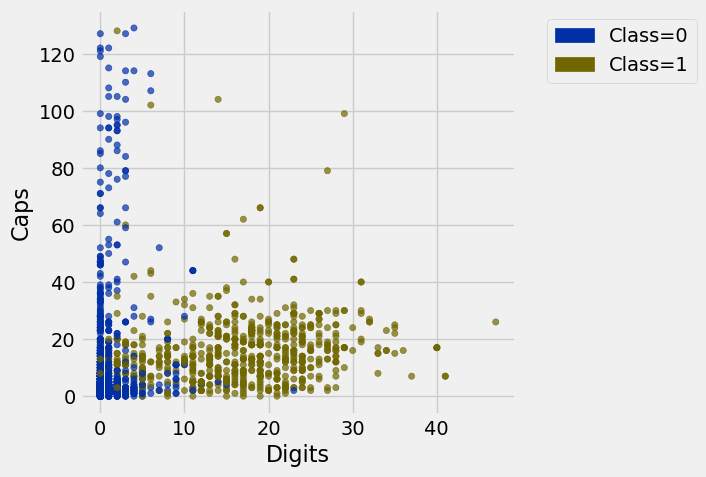

In [7]:
sms_data.scatter('Digits', 'Caps', group='Class')

In [8]:
shuffled = sms_data.sample(with_replacement=False)
test_size = 100
train_sms = shuffled.take(np.arange(test_size, shuffled.num_rows))
test_sms = shuffled.take(np.arange(test_size))

print('Training:', train_sms.num_rows, ' Test:', test_sms.num_rows)
evaluate_accuracy(train_sms, test_sms, 5)

Training: 5474  Test: 100


  0%|          | 0/100 [00:00<?, ?it/s]

0.97999999999999998

## Rotten Tomatoes Movie Reviews

In [9]:
reviews_full = load_dataset('rotten_tomatoes', split='train')
reviews_short = reviews_full.filter(lambda x: 5 <= len(x['text'].split()) <= 10)

reviews = Table().with_columns('Text', reviews_short['text'],
                               'Class', reviews_short['label'])
reviews = reviews.sample(with_replacement=False)  # Permute the rows
reviews.group('Class')

Class,count
0,529
1,543


In [10]:
reviews.sample(5)

Text,Class
it's fitfully funny but never really takes off .,0
the result is something quite fresh and delightful .,1
the fast runner' transports the viewer into an unusual space,1
"a mild , reluctant , thumbs down .",0
death might be a release .,0


In [11]:
words = [  # The most common adjectives in the data
    'good', 'bad', 'funny', 'little', 'much', 'new', 'best',
    'many', 'own', 'other', 'big', 'great', 'most', 'few',
    'real', 'first', 'full', 'american', 'romantic', 'same', 'old',
    'better', 'young', 'original', 'interesting', 'human',
    'hard', 'cinematic', 'enough', 'emotional', 'last', 'least', 'long',
    'true', 'predictable', 'visual', 'whole', 'high', 'special',
    'entertaining', 'sweet', 'enjoyable', 'narrative', 'familiar'
]
counts = Table(['Word', 'Positive', 'Negative'])
for word in words:
    has_word = reviews.where('Text', are.containing(word))
    counts = counts.with_row([word, has_word.where('Class', 1).num_rows,
                                    has_word.where('Class', 0).num_rows])

counts

Word,Positive,Negative
good,17,7
bad,2,8
funny,27,14
little,8,13
much,1,17
new,2,4
best,11,1
many,0,6
own,2,25
other,5,15


In [12]:
reviews.where('Text', are.containing('funny')).where('Class', 0).sample(5, with_replacement=False)

Text,Class
"not only unfunny , but downright repellent .",0
neither funny nor suspenseful nor particularly well-drawn .,0
a little weak -- and it isn't that funny .,0
what a stiflingly unfunny and unoriginal mess this is !,0
this strenuously unfunny showtime deserves the hook .,0


In [13]:
texts = reviews.column('Text')
review_words = Table().with_column('Class', reviews.column('Class'))
for word in words:
    review_words = review_words.with_column(word, np.char.count(np.char.lower(texts), word))

review_words.sample(5)

Class,good,bad,funny,little,much,new,best,many,own,other,big,great,most,few,real,first,full,american,romantic,same,old,better,young,original,interesting,human,hard,cinematic,enough,emotional,last,least,long,true,predictable,visual,whole,high,special,entertaining,sweet,enjoyable,narrative,familiar
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
train_reviews = review_words.take(np.arange(test_size, reviews.num_rows))
test_reviews = review_words.take(np.arange(test_size))

print('Word-count KNN:')
evaluate_accuracy(train_reviews, test_reviews, 5)

Word-count KNN:


  0%|          | 0/100 [00:00<?, ?it/s]

0.57999999999999996

In [15]:
classify_all(train_reviews, test_reviews, 5).pivot('Prediction', 'Class')

  0%|          | 0/100 [00:00<?, ?it/s]

Class,0.0,1.0
0,10,41
1,1,48


## Sentence Embeddings

Data 8 students are not responsible for learning the details of the code below, such as how to call `embedder.encode` or understanding what it does. 

In [18]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')
review_emb = embedder.encode(list(reviews.column('Text')), show_progress_bar=True)
print('Embedding shape:', review_emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Embedding shape: (1072, 384)


In [19]:
n_features = 384  # Increasing this will help, but above 128 datahub will crash

cols = ['Class', reviews.column('Class')]
for i in range(n_features):
    cols += [f'Embed{i}', review_emb[:, i]]

review_emb_table = Table().with_columns(*cols)
review_emb_table.row(0)

Row(Class=1, Embed0=0.019200735, Embed1=-0.033960462, Embed2=-0.0064136791, Embed3=0.03181849, Embed4=-0.040090643, Embed5=0.094549574, Embed6=0.052497644, Embed7=-0.0090332543, Embed8=0.14175008, Embed9=-0.040151011, Embed10=0.018321985, Embed11=-0.0025268409, Embed12=0.10903085, Embed13=-0.022248896, Embed14=-0.072498359, Embed15=0.0020178349, Embed16=-0.096268445, Embed17=-0.14937204, Embed18=0.064575993, Embed19=-0.011026557, Embed20=-0.0015952713, Embed21=0.11924704, Embed22=0.091237433, Embed23=-0.0199525, Embed24=0.033193659, Embed25=-0.051121421, Embed26=-0.024570983, Embed27=-0.01853261, Embed28=0.0062042526, Embed29=0.015071545, Embed30=-0.040215664, Embed31=0.055361636, Embed32=0.066318102, Embed33=0.031858876, Embed34=-0.018447991, Embed35=-0.039461486, Embed36=0.041817583, Embed37=-0.04022523, Embed38=0.0095656691, Embed39=0.04338371, Embed40=0.046871517, Embed41=-0.035502426, Embed42=0.041842945, Embed43=0.0083235353, Embed44=-0.053895228, Embed45=0.10517883, Embed46=-0.0

In [20]:
train = review_emb_table.take(np.arange(test_size, reviews.num_rows))
test = review_emb_table.take(np.arange(test_size))
evaluate_accuracy(train, test, 5)

  0%|          | 0/100 [00:00<?, ?it/s]

0.78000000000000003

In [21]:
classify_all(train, test, 5).pivot('Prediction', 'Class')

  0%|          | 0/100 [00:00<?, ?it/s]

Class,0.0,1.0
0,38,13
1,9,40


# BONUS MATERIAL

**WARNING:** Unfortunately, data8.datahub.berkeley.edu does not have enough RAM per student to run this code. Running the next cell will crash your kernel. It runs on a 2023 Macbook Air. Also, the code uses many features of Python and modules that we haven't covered in the course. Please don't feel like you have to understand it all.

### Fine-tuned embeddings


In [24]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = 'sentence-transformers/all-MiniLM-L6-v2'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

finetune_texts = list(reviews.column('Text')[test_size:])
finetune_labels = torch.tensor(list(reviews.column('Class')[test_size:]))

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
batch_size = 16

model.train()
for epoch in tqdm(range(7)):
    for i in range(0, len(finetune_texts), batch_size):
        batch_texts = finetune_texts[i:i+batch_size]
        batch_labels = finetune_labels[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=64)
        loss = model(**inputs, labels=batch_labels).loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/7 [00:00<?, ?it/s]

In [25]:
model.eval()
eval_texts = list(reviews.column('Text'))
with torch.no_grad():
    inputs = tokenizer(eval_texts, return_tensors='pt', padding=True, truncation=True, max_length=64)
    review_bert_emb = model.bert(**inputs).pooler_output.numpy()
print('Fine-tuned embedding shape:', review_bert_emb.shape)

Fine-tuned embedding shape: (1072, 384)


In [26]:
cols = ['Class', reviews.column('Class')]
for i in range(review_bert_emb.shape[1]):
    cols += [f'Embed{i}', review_bert_emb[:, i]]

review_bert_table = Table().with_columns(*cols)

train = review_bert_table.take(np.arange(test_size, reviews.num_rows))
test = review_bert_table.take(np.arange(test_size))

evaluate_accuracy(train, test, 5)

  0%|          | 0/100 [00:00<?, ?it/s]

0.81000000000000005

In [27]:
test_texts = list(reviews.column('Text')[:test_size])
test_labels = reviews.column('Class')[:test_size]

with torch.no_grad():
    inputs = tokenizer(test_texts, return_tensors='pt', padding=True, truncation=True, max_length=64)
    predictions = model(**inputs).logits.argmax(dim=1).numpy()

print('BERT classifier accuracy:', np.mean(predictions == test_labels))

BERT classifier accuracy: 0.83
